# 서울지하철 2호선 데이터 분석

- 범위: 지하철(2호선) 중심 분석, 버스 관련 분석 제외
- 데이터: 월별 승하차, 역 위치/주소, 역간거리, 출구별 주요장소, 혼잡도
- 목표:
  - 역별 수요 Top-N 및 공간적 분포
  - 출구별 주요장소 규모와 승하차의 상관 단서
  - 혼잡 시간대 프로파일(평일/시간대) 샘플 분석
  - 역간거리 기반 기본 이동 특성 파악

In [32]:
# 공통 라이브러리 및 유틸
import os
import pandas as pd
import numpy as np
from pathlib import Path
import re

# Matplotlib (한글 폰트 설정 포함)
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 지도 시각화는 Folium 사용(인터랙티브 지도용)
import folium
from folium.plugins import MarkerCluster

DATA_DIR = Path(r"C:/Users/THKIM/Desktop/3-2 프로젝트/스마트시티 문제해결 프로젝트/data")

# 다중 인코딩 시도 로더
ENCODINGS = ["utf-8-sig", "cp949", "euc-kr", "utf-8", "latin1"]

def read_csv_multi(path, **kwargs):
    last_err = None
    for enc in ENCODINGS:
        try:
            return pd.read_csv(path, encoding=enc, **kwargs)
        except Exception as e:
            last_err = e
            continue
    raise last_err

# 역명 정리: 공백, 제로폭문자, 괄호 내 보조표기 제거
def clean_station_name(s):
    if pd.isna(s):
        return s
    s = str(s).strip().replace("\u200b", "")
    s = re.sub(r"\(.*?\)", "", s)  # 괄호 내용 제거
    s = s.replace(" ", "")
    return s

print("환경 준비 완료. 데이터 디렉터리:", DATA_DIR), ""

환경 준비 완료. 데이터 디렉터리: C:\Users\THKIM\Desktop\3-2 프로젝트\스마트시티 문제해결 프로젝트\data


(None, '')

In [33]:
# 데이터 로드 (버스 제외, 지하철 2호선만)
CARD_PATH = DATA_DIR / "CARD_SUBWAY_MONTH_202510.csv"
LOC_PATH = DATA_DIR / "국가철도공단_수도권2호선_역위치_20240624.csv"
DIST_PATH = DATA_DIR / "국가철도공단_수도권2호선_역간거리_20241015.csv"
POI_PATH = DATA_DIR / "국가철도공단_수도권2호선 출구별 주요장소_20240822.csv"
ADDR_PATH = DATA_DIR / "국가철도공단_수도권2호선_주소데이터_20241022.csv"
CONG_PATH = DATA_DIR / "서울교통공사_지하철혼잡도정보_20250630.csv"

# ----------------------
# 역간거리(km): 2호선 역명 추출의 기준 (견고 파서)
# ----------------------
dist_raw = read_csv_multi(DIST_PATH)
dist_raw.columns = [str(c).strip() for c in dist_raw.columns]

# 거리 컬럼 탐지 (이름 우선: '거리'/'km' 포함 → 값 범위로 보완)
num_cols = [c for c in dist_raw.columns if pd.api.types.is_numeric_dtype(dist_raw[c])]
dist_col = None
for c in dist_raw.columns:
    name = str(c)
    if ('거리' in name) or ('km' in name.lower()):
        dist_col = c
        break
if dist_col is None:
    cand_num = []
    for c in num_cols:
        s = pd.to_numeric(dist_raw[c], errors='coerce')
        if s.notna().sum() == 0:
            continue
        if s.min() >= 0 and s.max() <= 10:
            cand_num.append(c)
    dist_col = cand_num[0] if cand_num else (num_cols[0] if num_cols else None)

# 역명 컬럼 탐지: 한글 포함 비율/유일값 수로 판단
obj_cols = [c for c in dist_raw.columns if dist_raw[c].dtype == 'object']
def _is_station_like(series):
    s = series.dropna().astype(str).str.strip()
    if s.empty:
        return False
    ratio_ko = s.str.contains(r'[가-힣]', regex=True).mean()
    return (s.nunique() >= 20) and (ratio_ko > 0.5)

name_cands = [c for c in obj_cols if _is_station_like(dist_raw[c])]
if '이전역' in dist_raw.columns and '현재역' in dist_raw.columns:
    prev_col, curr_col = '이전역', '현재역'
elif len(name_cands) >= 2:
    prev_col, curr_col = name_cands[:2]
else:
    like_prev = next((c for c in dist_raw.columns if ('이전' in str(c)) or ('from' in str(c).lower())), None)
    like_curr = next((c for c in dist_raw.columns if ('현재' in str(c)) or ('다음' in str(c)) or ('to' in str(c).lower())), None)
    prev_col = like_prev or (name_cands[0] if name_cands else None)
    curr_col = like_curr or (name_cands[1] if len(name_cands) > 1 else None)

# 컬럼 조합에 따른 분기: (1) 두 역명 컬럼이 모두 있는 경우 (2) 역명 하나 + 거리(다음역까지)인 경우
if (prev_col is not None) and (curr_col is not None) and (dist_col is not None):
    distdf = pd.DataFrame({
        '노선명': dist_raw['노선명'] if '노선명' in dist_raw.columns else '2호선',
        '이전역': dist_raw[prev_col],
        '현재역': dist_raw[curr_col],
        '역간거리_km': pd.to_numeric(dist_raw[dist_col], errors='coerce')
    })
elif (prev_col is not None) and (curr_col is None) and (dist_col is not None):
    # 역명 단일열 + 다음역까지 거리 → 연속 행을 엣지로 해석
    seq = dist_raw[prev_col].map(clean_station_name)
    w = pd.to_numeric(dist_raw[dist_col], errors='coerce').fillna(1.0)
    # 순환선 처리를 위한 순서 보존 리스트(강한 정규화 키) 보관
    _seq_key = seq.map(lambda x: re.sub(r'역$', '', x) if isinstance(x, str) else x)
    line2_seq = _seq_key.dropna().tolist()
    line2_last_w = float(w.iloc[-1]) if len(w) > 0 else 1.0
    distdf = pd.DataFrame({
        '노선명': dist_raw['노선명'] if '노선명' in dist_raw.columns else '2호선',
        '이전역': seq,
        '현재역': seq.shift(-1),
        '역간거리_km': w
    }).dropna(subset=['이전역','현재역'])
else:
    print('역간거리 CSV 컬럼 탐지 실패:', {'prev':prev_col,'curr':curr_col,'dist':dist_col})
    raise ValueError('역간거리 컬럼 자동 탐지 실패')

# ★ 정규화 전 원본 역명으로 2호선 셋 구축
line2_raw = set(pd.unique(pd.concat([distdf['이전역'], distdf['현재역']], ignore_index=True).dropna()))

# 이후 분석용 정규화 컬럼 추가
for c in ['이전역','현재역']:
    if c in distdf:
        distdf[c+'_norm'] = distdf[c].map(clean_station_name)

dist2 = distdf.copy()

# 정규화 후 2호선 역명 셋 (그래프 등 나중 분석용)
line2_stations = set(pd.unique(pd.concat([dist2['이전역_norm'], dist2['현재역_norm']], ignore_index=True).dropna()))

# 강한 정규화 키 (말미 '역' 제거)용 셋
line2_keys = set(re.sub(r"역$", "", s) if isinstance(s, str) else s for s in line2_stations)

# ----------------------
# 역 위치(경도/위도)
# ----------------------
loc = read_csv_multi(LOC_PATH)
loc_cols = list(loc.columns)
if len(loc_cols) >= 5:
    loc = loc.iloc[:, [1,2,3,4]]
    loc.columns = ["노선명","역명","경도","위도"]
else:
    loc.columns = [f"col{i}" for i in range(len(loc.columns))]
    loc["노선명"] = loc.iloc[:,1]
    loc["역명"] = loc.iloc[:,2]
    loc["경도"] = loc.iloc[:,-2]
    loc["위도"] = loc.iloc[:,-1]
loc["역명_norm"] = loc["역명"].map(clean_station_name)
loc2 = loc.copy()

# ----------------------
# 월별 승하차 (서울교통공사 카드 데이터)
# ----------------------
card_raw = pd.read_csv(CARD_PATH, encoding='utf-8-sig', header=0, index_col=False)
# 빈 열 drop, 컬럼명 정리
card_raw = card_raw.loc[:, card_raw.columns.notnull()]
card_raw.columns = [str(c).strip().replace('\"','') for c in card_raw.columns]
# 경우에 따라 마지막 빈 문자열 컬럼이 있다면 제거
if '' in card_raw.columns:
    card_raw = card_raw.drop(columns=[''])

# 헤더 검증
expected = {'사용일자','노선명','역명','승차총승객수','하차총승객수'}
if not expected.issubset(set(card_raw.columns)):
    # 만약 컬럼명이 다르면 샘플 출력 후 종료
    print("카드 데이터 실제 컬럼:", list(card_raw.columns))
    print("샘플 5행:")
    print(card_raw.head())
    raise ValueError("컬럼명 불일치")

# 필요 컬럼만 선택 및 타입 변환
card = card_raw[['사용일자','노선명','역명','승차총승객수','하차총승객수']].copy()
card.reset_index(drop=True, inplace=True)

# 역명 정규화 및 수치 변환
card["역명_norm"] = card["역명"].map(clean_station_name)
# 강한 정규화 키 (말미 '역' 제거)
card["역명_key"] = card["역명_norm"].map(lambda s: re.sub(r"역$", "", str(s)) if pd.notna(s) else s)
card["승차총승객수"] = pd.to_numeric(card["승차총승객수"], errors='coerce')
card["하차총승객수"] = pd.to_numeric(card["하차총승객수"], errors='coerce')
card["총이용객수"] = card["승차총승객수"].fillna(0) + card["하차총승객수"].fillna(0)

# 필터: 강한 정규화 키 기반 2호선 추출 (12개 역 누락 방지)
card2 = card[card["역명_key"].isin(line2_keys)].copy()

# ----------------------
# 출구별 주요장소
# ----------------------
poi = read_csv_multi(POI_PATH)
if len(poi.columns) >= 5:
    poi = poi.iloc[:, [1,2,3,4]]
    poi.columns = ["노선명","역명","출구번호","주요장소"]
else:
    poi.columns = [f"col{i}" for i in range(len(poi.columns))]
    poi = poi.rename(columns={poi.columns[1]:"노선명", poi.columns[2]:"역명"})
poi["역명_norm"] = poi["역명"].map(clean_station_name)
poi2 = poi.copy()

# ----------------------
# 주소 데이터 (필요 시 역명 매칭용)
# ----------------------
addr = read_csv_multi(ADDR_PATH)
if len(addr.columns) >= 5:
    addr = addr.iloc[:, [1,2,3,4]]
    addr.columns = ["노선명","역명","도로명주소","지번주소"]
else:
    addr.columns = [f"col{i}" for i in range(len(addr.columns))]
    addr = addr.rename(columns={addr.columns[1]:"노선명", addr.columns[2]:"역명"})
addr["역명_norm"] = addr["역명"].map(clean_station_name)
addr2 = addr.copy()

# ----------------------
# 혼잡도 데이터 (시간대 폭 넓음 → 일부 역 샘플 분석)
# ----------------------
cong = read_csv_multi(CONG_PATH)
cong.columns = [c.strip() for c in cong.columns]
time_cols = [c for c in cong.columns if ":" in c or "00��" in c or "30" in c]
base_cols = cong.columns[:4].tolist()
cong2 = cong[base_cols + time_cols].copy()

print("데이터 적재 완료:")
print({
    "card2(2호선)": card2.shape,
    "loc2": loc2.shape,
    "dist2": dist2.shape,
    "poi2": poi2.shape,
    "addr2": addr2.shape,
    "cong2": cong2.shape,
})


데이터 적재 완료:
{'card2(2호선)': (2387, 8), 'loc2': (51, 5), 'dist2': (50, 6), 'poi2': (1690, 5), 'addr2': (51, 5), 'cong2': (1671, 24)}


In [3]:
# 실패 시 원본 dist_raw 상태 확인
try:
    print('dist_raw 컬럼:', list(dist_raw.columns))
    print(dist_raw.head(10))
except NameError:
    print('dist_raw 미정의: 위 셀에서 생성 실패')

dist_raw 컬럼: ['철도운영기관명', '선명', '역명', '역간거리(km)']
  철도운영기관명   선명         역명  역간거리(km)
0  서울교통공사  2호선         시청       1.1
1  서울교통공사  2호선      을지로입구       0.7
2  서울교통공사  2호선      을지로3가       0.8
3  서울교통공사  2호선      을지로4가       0.6
4  서울교통공사  2호선  동대문역사문화공원       1.0
5  서울교통공사  2호선         신당       0.9
6  서울교통공사  2호선       상왕십리       0.9
7  서울교통공사  2호선        왕십리       0.8
8  서울교통공사  2호선        한양대       1.0
9  서울교통공사  2호선         뚝섬       1.1


In [4]:
# 디버그: 역간거리 원본 컬럼/샘플 확인
print("distdf 컬럼:", list(distdf.columns))
print(distdf.dtypes)
print(distdf.head(3))

distdf 컬럼: ['노선명', '이전역', '현재역', '역간거리_km', '이전역_norm', '현재역_norm']
노선명          object
이전역          object
현재역          object
역간거리_km     float64
이전역_norm     object
현재역_norm     object
dtype: object
   노선명    이전역    현재역  역간거리_km 이전역_norm 현재역_norm
0  2호선     시청  을지로입구      1.1       시청    을지로입구
1  2호선  을지로입구  을지로3가      0.7    을지로입구    을지로3가
2  2호선  을지로3가  을지로4가      0.8    을지로3가    을지로4가


In [34]:
# 기본 분석 테이블 생성 (역명_norm 기준 집계)
# 1) 역별 총이용객수 Top 15
by_station = (card2.groupby("역명_norm", as_index=False)[["승차총승객수","하차총승객수","총이용객수"]]
              .sum().sort_values("총이용객수", ascending=False))
TOPN = 15
top_stations = by_station.head(TOPN)

# 2) 역별 POI(주요장소) 개수
poi_counts = (poi2.groupby("역명_norm", as_index=False)
              .agg(POI수=("주요장소","count")))

# 3) 역간거리 기초 통계 (정규화 컬럼 사용)
dist_stats = {
    "구간수": int(dist2.shape[0]),
    "평균 역간거리(km)": float(pd.to_numeric(dist2.get("역간거리_km"), errors="coerce").dropna().mean()),
    "최대 역간거리(km)": float(pd.to_numeric(dist2.get("역간거리_km"), errors="coerce").dropna().max()),
    "최소 역간거리(km)": float(pd.to_numeric(dist2.get("역간거리_km"), errors="coerce").dropna().min()),
}

print("Top 5 확인:")
print(top_stations.head(5))
print("\nPOI 개수 상위 5:")
print(poi_counts.sort_values("POI수", ascending=False).head(5))
print("\n역간거리 통계:")
print(dist_stats)


Top 5 확인:
   역명_norm   승차총승객수   하차총승객수    총이용객수
43      잠실  2889841  2953732  5843573
50    홍대입구  2799163  2986175  5785338
0       강남  2147151  2114257  4261408
16      사당  1912260  1943416  3855676
21      선릉  1763641  1742787  3506428

POI 개수 상위 5:
   역명_norm  POI수
19   서울대입구    69
16      사당    68
22      성수    64
38   을지로입구    63
36   을지로3가    58

역간거리 통계:
{'구간수': 50, '평균 역간거리(km)': 1.1260000000000001, '최대 역간거리(km)': 2.0, '최소 역간거리(km)': 0.0}


In [6]:
# 추가 진단: 카드 데이터에서 역명 후보 열과 2호선 역 교집합 크기 확인
line2 = set(pd.unique(pd.concat([dist2['이전역'], dist2['현재역']], ignore_index=True).dropna()))
obj_cols = [c for c in card.columns if card[c].dtype == 'object']
for c in obj_cols:
    vals = card[c].astype(str).map(clean_station_name)
    inter = set(vals.unique()).intersection(line2)
    print(c, '교집합 크기:', len(inter))
    if len(inter) > 0:
        print('예시:', list(sorted(inter))[:10])


노선명 교집합 크기: 0
역명 교집합 크기: 51
예시: ['강남', '강변', '건대입구', '교대', '구로디지털단지', '구의', '까치산', '낙성대', '당산', '대림']
역명_norm 교집합 크기: 51
예시: ['강남', '강변', '건대입구', '교대', '구로디지털단지', '구의', '까치산', '낙성대', '당산', '대림']
역명_norm 교집합 크기: 51
예시: ['강남', '강변', '건대입구', '교대', '구로디지털단지', '구의', '까치산', '낙성대', '당산', '대림']


In [7]:
# 교차 여부 및 card2 필터 논리 점검
print('역명(정규화) 샘플:', card['역명'].astype(str).head().tolist())
print('2호선 역 교집합 건수:', card['역명'].isin(line2).sum())


역명(정규화) 샘플: ['중계', '종로3가', '종로5가', '동대문', '신설동']
2호선 역 교집합 건수: 1767


In [8]:
# 원본 카드 데이터 컬럼명 확인
print(list(card.columns))


['사용일자', '노선명', '역명', '승차총승객수', '하차총승객수', '역명_norm', '총이용객수']


In [9]:
# 데이터 로드 시 선택된 컬럼 이름 확인
try:
    print('station_col =', station_col)
    print('board_col   =', board_col)
    print('alight_col  =', alight_col)
except NameError:
    print('선택 변수 확인 불가: 데이터 로드 셀을 먼저 실행하세요')


선택 변수 확인 불가: 데이터 로드 셀을 먼저 실행하세요


In [10]:
# 현재 숫자 컬럼 분포 재점검 (date vs count 분리 여부 확인)
cols_to_check = ['승차총승객수','하차총승객수','총이용객수']
card2_sample = card2[cols_to_check].describe().T
print(card2_sample)


         count          mean           std    min      25%      50%      75%  \
승차총승객수  1767.0  20285.276740  18847.681026  187.0   5985.0  15410.0  27804.0   
하차총승객수  1767.0  20594.391058  19299.932766  202.0   5977.5  15504.0  27380.5   
총이용객수   1767.0  40879.667799  38088.662532  389.0  12012.0  31192.0  54696.5   

             max  
승차총승객수   99073.0  
하차총승객수  114929.0  
총이용객수   212613.0  


In [11]:
# 2호선 역명과 card 열 매칭 디버깅
print('line2_stations 샘플:', sorted(list(line2_stations))[:10])
print('\ncard 역명 고유값 샘플:', sorted(card['역명'].dropna().unique())[:10])
print('\n교집합:', set(card['역명'].unique()).intersection(line2_stations))


line2_stations 샘플: ['강남', '강변', '건대입구', '교대', '구로디지털단지', '구의', '까치산', '낙성대', '당산', '대림']

card 역명 고유값 샘플: ['4.19민주묘지', '가능', '가락시장', '가산디지털단지', '가양', '가오리', '가좌', '가천대', '가평', '간석']

교집합: {'신림', '잠실새내', '까치산', '선릉', '이대', '한양대', '신설동', '잠실나루', '을지로입구', '당산', '역삼', '건대입구', '문래', '성수', '강남', '용답', '홍대입구', '구로디지털단지', '을지로4가', '아현', '상왕십리', '서초', '신도림', '봉천', '신촌', '신정네거리', '을지로3가', '신당', '신대방', '사당', '뚝섬', '신답', '영등포구청', '종합운동장', '합정', '시청', '양천구청', '도림천', '방배'}


In [12]:
# card2 행별 샘플 확인 (원본 역명, 정규화 역명, 승하차)
print("card2 (2호선) 샘플 5행:")
print(card2[["역명","역명_norm","승차총승객수","하차총승객수","총이용객수"]].head())


card2 (2호선) 샘플 5행:
       역명 역명_norm  승차총승객수  하차총승객수   총이용객수
4     신설동     신설동   16055   15400   31455
8      시청      시청   31493   30490   61983
9   을지로입구   을지로입구   53526   55765  109291
10  을지로3가   을지로3가   27935   28000   55935
11  을지로4가   을지로4가   16964   16667   33631


In [13]:
# 더 넓은 범위의 원본 데이터 확인 (row 489)
print("card_raw (필터 전) row 489 주변:")
print(card.iloc[485:495][["사용일자","노선명","역명","승차총승객수","하차총승객수"]])


card_raw (필터 전) row 489 주변:
         사용일자  노선명      역명  승차총승객수  하차총승객수
485  20251001  분당선      구룡    4165    4111
486  20251001  분당선     개포동    5237    5210
487  20251001  분당선   대모산입구    6695    6381
488  20251001  분당선      수서   18835   20144
489  20251001  분당선      복정       2       0
490  20251001  분당선      수원    8564    7863
491  20251001  분당선     서울숲   13115   13613
492  20251001  분당선  압구정로데오   20093   21960
493  20251001  분당선    강남구청   10997   12807
494  20251001  분당선     선정릉    8562    8782


In [14]:
# 숫자열 요약으로 승/하차 후보 파악
summary = []
for c in card.columns:
    s = pd.to_numeric(card[c], errors='coerce')
    nn = s.notna().sum()
    if nn == 0:
        continue
    uniq = s.nunique(dropna=True)
    sm = float(s.sum(skipna=True))
    mn = float(s.min(skipna=True))
    mx = float(s.max(skipna=True))
    med = float(s.median(skipna=True))
    summary.append((c, nn, uniq, sm, mn, mx, med))
summary_df = pd.DataFrame(summary, columns=['col','non_na','nunique','sum','min','max','median']).sort_values('sum', ascending=False)
print(summary_df.head(10))


      col  non_na  nunique           sum         min         max      median
0    사용일자   19127       31  3.873412e+11  20251001.0  20251031.0  20251016.0
3   총이용객수   19127    15372  4.120615e+08         1.0    212613.0     14726.0
1  승차총승객수   19127    12884  2.065292e+08         1.0     99073.0      7458.0
2  하차총승객수   19127    12841  2.055322e+08         0.0    114929.0      7221.0


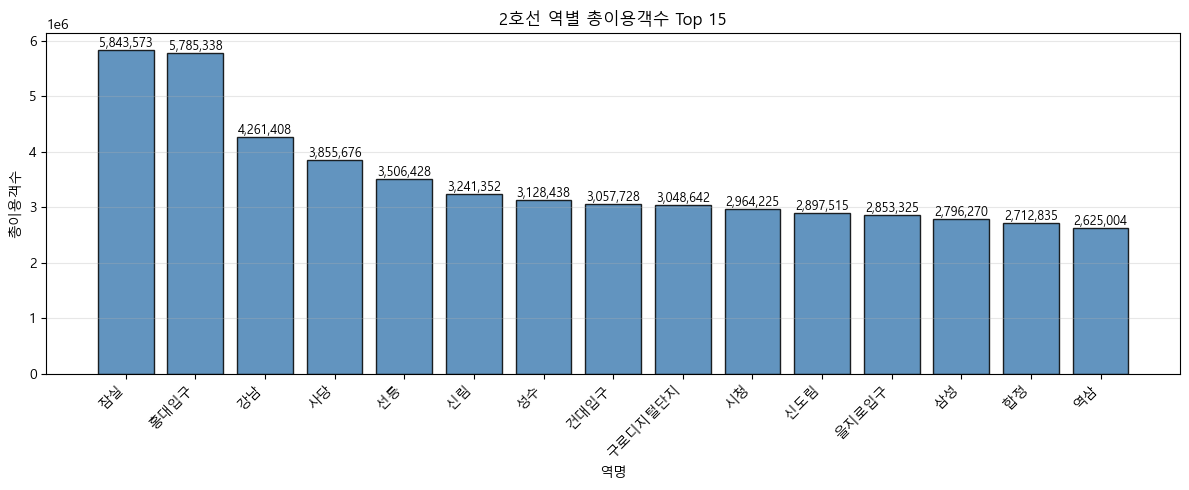

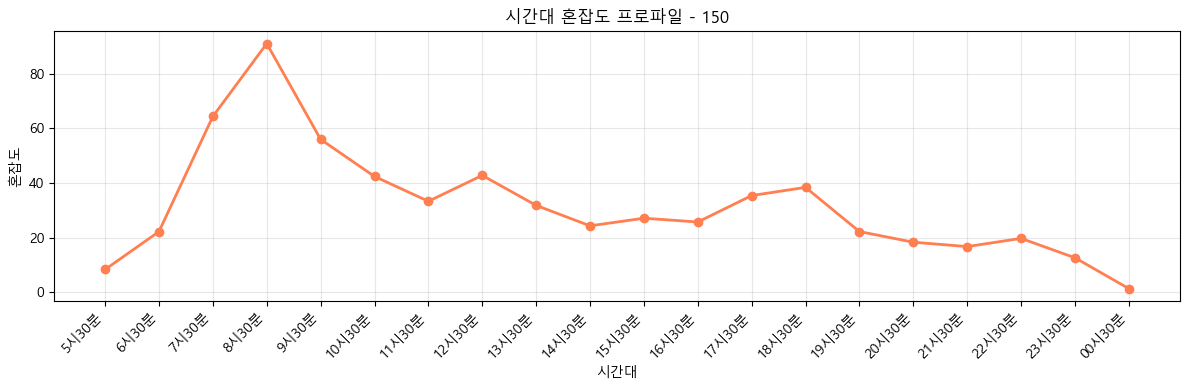

In [35]:
# Matplotlib 시각화: Top-N 역 이용량, 혼잡도 프로파일
import matplotlib.pyplot as plt

# 한글 폰트 및 마이너스 표시 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 1) Top-N 역 이용량 막대 그래프 (역명_norm 사용)
plt.figure(figsize=(12, 5))
plt.bar(top_stations['역명_norm'], top_stations['총이용객수'], color='steelblue', edgecolor='black', alpha=0.85)
plt.title(f"2호선 역별 총이용객수 Top {TOPN}")
plt.xlabel('역명')
plt.ylabel('총이용객수')
plt.xticks(rotation=45, ha='right')
# 값 라벨 표시
for i, v in enumerate(top_stations['총이용객수'].values):
    plt.text(i, v, f"{int(v):,}", ha='center', va='bottom', fontsize=9)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 2) 혼잡도: 특정 역 시간대 프로파일(존재 시 강남, 없으면 첫 행)
station_col_candidates = [c for c in cong2.columns[:4] if any(k in c for k in ['역', '정거장', 'Station'])]
station_col = station_col_candidates[0] if station_col_candidates else cong2.columns[2]

if (cong2[station_col].astype(str) == '강남').any():
    cong_row = cong2[cong2[station_col].astype(str) == '강남'].iloc[0]
else:
    cong_row = cong2.iloc[0]

times = [c for c in cong2.columns if c not in cong2.columns[:4]]
cong_series = pd.to_numeric(cong_row[times], errors='coerce')
cong_df = pd.DataFrame({'시간대': times, '혼잡도': cong_series.values})

plt.figure(figsize=(12, 4))
plt.plot(cong_df['시간대'], cong_df['혼잡도'], marker='o', color='coral', linewidth=2)
plt.title(f"시간대 혼잡도 프로파일 - {str(cong_row[station_col])}")
plt.xlabel('시간대')
plt.ylabel('혼잡도')
plt.xticks(rotation=45, ha='right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [16]:
# Folium 지도: 역 위치 + 이용규모 시각화 (원 크기 ~ 총이용객수)

# 위치 + 이용량 결합 (역명_norm 기준)
loc_merged = pd.merge(loc2, by_station, on="역명_norm", how="left")

# 숫자형 변환 및 결측 보정
for col in ["위도", "경도", "승차총승객수", "하차총승객수", "총이용객수"]:
    if col in loc_merged.columns:
        loc_merged[col] = pd.to_numeric(loc_merged[col], errors="coerce")

loc_merged[["승차총승객수", "하차총승객수", "총이용객수"]] = \
    loc_merged[["승차총승객수", "하차총승객수", "총이용객수"]].fillna(0)

# 안전한 정수 포맷터
def fmt_int(x):
    try:
        v = float(x)
    except Exception:
        v = 0
    if pd.isna(v):
        v = 0
    return f"{int(round(v)):,}"

center_lat = loc_merged["위도"].mean()
center_lon = loc_merged["경도"].mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=11, tiles="OpenStreetMap")
cluster = MarkerCluster().add_to(m)

# 점 크기 스케일링
scale = max(loc_merged["총이용객수"].max(), 1)
for _, r in loc_merged.dropna(subset=["위도", "경도"]).iterrows():
    total_val = r["총이용객수"] if pd.notna(r["총이용객수"]) else 0
    size = 3 + 15 * (float(total_val) / scale)  # 3~18 사이
    # 역명: 원본이 있으면 사용, 없으면 역명_norm
    station_name = r.get('역명', r['역명_norm'])
    popup_html = (
        f"<b>{station_name}</b><br>"
        f"총이용객수: {fmt_int(r['총이용객수'])}<br>"
        f"승차: {fmt_int(r.get('승차총승객수', 0))} / 하차: {fmt_int(r.get('하차총승객수', 0))}"
    )
    popup = folium.Popup(popup_html, max_width=300)
    folium.CircleMarker(
        location=[r["위도"], r["경도"]],
        radius=size,
        color="#3186cc",
        fill=True,
        fill_opacity=0.6,
        popup=popup
    ).add_to(cluster)

m

## 네트워크 중심성 분석 (서울 2호선)
- 네트워크: 노드=역, 엣지=역-역 연결(가중치=역간거리 km, 결측 시 1)
- 지표: Betweenness(매개), Closeness(근접), Traffic-flow Centrality(OD 가중)
- 데이터: `card2`(승·하차), `dist2`(역간거리), `loc2`(좌표)
- 버스 분석 제외


In [36]:
# NetworkX 그래프 구성 (2호선)
import networkx as nx

# 강한 정규화 키: 공백/괄호 제거 + 말미 '역' 제거
def station_key(s):
    if pd.isna(s):
        return s
    x = clean_station_name(s)
    if pd.isna(x):
        return x
    x = re.sub(r"역$", "", str(x))
    return x

# dist2 기반 엣지 테이블 구성 → 정규화 키로 통일
edges = dist2[["이전역","현재역","역간거리_km"]].copy()
edges["u"] = edges["이전역"].map(station_key)
edges["v"] = edges["현재역"].map(station_key)
# 결측/자가루프 제거
edges = edges.dropna(subset=["u","v"])
edges = edges[edges["u"] != edges["v"]]
# 가중치 수치화 (결측=1km)
edges["w"] = pd.to_numeric(edges["역간거리_km"], errors="coerce").fillna(1.0).astype(float)

# (u,v) 무방향 중복 엣지 통합: 최소 거리 사용
edges["key"] = edges.apply(lambda r: tuple(sorted((str(r["u"]), str(r["v"])))), axis=1)
edges_agg = edges.groupby("key", as_index=False)["w"].min()
edges_agg[["u","v"]] = pd.DataFrame(edges_agg["key"].tolist(), index=edges_agg.index)

# 그래프 빌드
nodes = sorted(set(edges_agg["u"]).union(edges_agg["v"]))
G = nx.Graph()
G.add_nodes_from(nodes)
for _, r in edges_agg.iterrows():
    G.add_edge(r["u"], r["v"], weight=float(r["w"]))

# 순환선이면 마지막-첫번째 엣지 보강 (데이터 로드 셀에서 line2_seq/line2_last_w 제공 시)
try:
    if 'line2_seq' in globals() and isinstance(line2_seq, list) and len(line2_seq) >= 2:
        first_k = str(line2_seq[0])
        last_k = str(line2_seq[-1])
        close_w = float(line2_last_w) if 'line2_last_w' in globals() else 1.0
        if (first_k in G) and (last_k in G) and (not G.has_edge(last_k, first_k)):
            G.add_edge(last_k, first_k, weight=close_w)
except Exception:
    pass

print(f"노드 수: {G.number_of_nodes()}, 엣지 수: {G.number_of_edges()}")
# 연결성 진단
comp_sizes = [len(c) for c in nx.connected_components(G)]
print(f"연결 컴포넌트 수: {len(comp_sizes)}, 상위 크기: {sorted(comp_sizes, reverse=True)[:5]}")
iso = [n for n, deg in G.degree() if deg == 0]
print(f"차수 0 노드 수: {len(iso)}")

노드 수: 51, 엣지 수: 51
연결 컴포넌트 수: 1, 상위 크기: [51]
차수 0 노드 수: 0


In [18]:
# 보강 엣지 상태 확인
try:
    print('line2_seq exists?', 'line2_seq' in globals())
    if 'line2_seq' in globals():
        print('len(line2_seq)=', len(line2_seq))
        first_k = str(line2_seq[0])
        last_k = str(line2_seq[-1])
        print('first,last:', first_k, last_k, 'has_edge?', G.has_edge(last_k, first_k))
except Exception as e:
    print('closing-edge check error:', e)

line2_seq exists? True
len(line2_seq)= 51
first,last: 시청 용두 has_edge? True


In [37]:
# Betweenness / Closeness 계산 (가중치=역간거리_km)
# betweenness: weight 사용, normalized=True
node_bc = nx.betweenness_centrality(G, weight='weight', normalized=True)
node_cc = nx.closeness_centrality(G, distance='weight')

cent_df = pd.DataFrame({
    '역명': list(node_bc.keys()),
    'betweenness': list(node_bc.values()),
    'closeness': [node_cc[n] for n in node_bc.keys()]
})

# 강한 정규화 키: 공백/괄호 제거 + 말미 '역' 제거
def station_key(s):
    if pd.isna(s):
        return s
    x = clean_station_name(s)
    if pd.isna(x):
        return x
    x = re.sub(r"역$", "", str(x))
    return x

# 그래프 노드 키
cent_df['역명_key'] = cent_df['역명'].map(station_key)

# 승하차 집계: 정규화 역명에서 키를 도출
usage = (card2.groupby('역명_norm', as_index=False)
         [['승차총승객수','하차총승객수','총이용객수']].sum())
usage['역명_key'] = usage['역명_norm'].map(station_key)

# 병합은 키 기준
cent_merged = usage.merge(
    cent_df[['역명_key','betweenness','closeness']], on='역명_key', how='left'
)

# 매칭율 진단(선택적)
matched = cent_merged['betweenness'].notna().sum()
print(f"중앙성 병합 매칭 개수: {matched} / {len(cent_merged)}")
print(cent_merged.sort_values('betweenness', ascending=False).head(10))


중앙성 병합 매칭 개수: 51 / 51
      역명_norm   승차총승객수   하차총승객수    총이용객수     역명_key  betweenness  closeness
10        도림천    36304    37871    74175        도림천     0.401633   0.071266
29        신설동   587486   562388  1149874        신설동     0.397959   0.071266
25         신당   657258   674995  1332253         신당     0.271633   0.072464
11  동대문역사문화공원  1140614  1146094  2286708  동대문역사문화공원     0.271429   0.072558
40      을지로4가   589870   583097  1172967      을지로4가     0.271224   0.072590
18       상왕십리   398859   391541   790400       상왕십리     0.271020   0.072369
39      을지로3가  1044643  1036447  2081090      을지로3가     0.271020   0.072558
41      을지로입구  1417592  1435733  2853325      을지로입구     0.270000   0.072485
36        왕십리  1066024  1050228  2116252        왕십리     0.269592   0.072098
23         시청  1510003  1454222  2964225         시청     0.268163   0.072359


In [20]:
# 진단: 가중치 미사용 시 betweenness 확인
import numpy as np
bc_unw = nx.betweenness_centrality(G, normalized=True, weight=None)
max_bc = max(bc_unw.values()) if bc_unw else 0
print("무가중치 betweenness 최대값:", max_bc)
print(sorted([(k, v) for k, v in bc_unw.items()], key=lambda x: x[1], reverse=True)[:10])

무가중치 betweenness 최대값: 0.2448979591836735
[('강남', 0.2448979591836735), ('강변', 0.2448979591836735), ('건대입구', 0.2448979591836735), ('교대', 0.2448979591836735), ('구로디지털단지', 0.2448979591836735), ('구의', 0.2448979591836735), ('까치산', 0.2448979591836735), ('낙성대', 0.2448979591836735), ('당산', 0.2448979591836735), ('대림', 0.2448979591836735)]


In [38]:
# Traffic-flow centrality (수요 가중 매개 중심성) 간단 구현
# OD 수요 근사: 승차_s * 하차_t 를 수요 D_{st}로 사용 (대안: 총이용객수 곱)
from collections import defaultdict

# station_key 재사용 (위 셀과 동일)
def station_key(s):
    if pd.isna(s):
        return s
    x = clean_station_name(s)
    if pd.isna(x):
        return x
    x = re.sub(r"역$", "", str(x))
    return x

# 역 인덱싱 및 수요 준비 (강한 정규화 키 기준)
board = usage.set_index('역명_key')['승차총승객수'].to_dict()
alight = usage.set_index('역명_key')['하차총승객수'].to_dict()

stations_list = list(G.nodes())

node_tfc = defaultdict(float)
edge_tfc = defaultdict(float)

for s in stations_list:
    # 단일 소스 최단경로 트리 (거리/부모)
    try:
        lengths, paths = nx.single_source_dijkstra(G, source=s, weight='weight')
    except Exception:
        # 분리 컴포넌트 보호
        continue
    for t in stations_list:
        if s == t or t not in paths:
            continue
        # 수요 가중치 (그래프 노드명을 키로 정규화하여 dict 조회)
        s_key = station_key(s)
        t_key = station_key(t)
        D_st = float(board.get(s_key, 0)) * float(alight.get(t_key, 0))
        if D_st <= 0:
            continue
        path = paths[t]
        # 노드 기여(시작/끝 제외) - 정규화 키 사용
        for v in path[1:-1]:
            vn = station_key(v)
            node_tfc[vn] += D_st
        # 엣지 기여(연속 구간) — 키는 문자열 정렬 튜플로 보관
        for i in range(len(path)-1):
            su, sv = str(path[i]), str(path[i+1])
            e = tuple(sorted((su, sv)))
            edge_tfc[e] += D_st

node_tfc_df = pd.DataFrame({'역명_key': list(node_tfc.keys()), 'tfc': list(node_tfc.values())})
# 병합 키는 강한 정규화 키 기준
cent_all = (
    cent_merged.merge(node_tfc_df, on='역명_key', how='left')
    .fillna({'tfc': 0})
)

print(cent_all.sort_values('tfc', ascending=False).head(10))


   역명_norm   승차총승객수   하차총승객수    총이용객수 역명_key  betweenness  closeness  \
20      서초   586818   563395  1150213     서초     0.221224   0.065317   
14      방배   472575   484009   956584     방배     0.220204   0.065257   
3       교대  1223892  1191437  2415329     교대     0.222857   0.065411   
34      역삼  1235054  1389950  2625004     역삼     0.227347   0.065946   
46   종합운동장   494911   536287  1031198  종합운동장     0.236531   0.067331   
45    잠실새내   663173   655158  1318331   잠실새내     0.239592   0.067852   
7      낙성대   781492   756575  1538067    낙성대     0.216531   0.064658   
21      선릉  1763641  1742787  3506428     선릉     0.230408   0.066401   
0       강남  2147151  2114257  4261408     강남     0.225102   0.065617   
17      삼성  1392699  1403571  2796270     삼성     0.233469   0.066800   

             tfc  
20  6.976757e+14  
14  6.975745e+14  
3   6.748213e+14  
34  6.733020e+14  
46  6.650324e+14  
45  6.491472e+14  
7   6.474230e+14  
21  6.409894e+14  
0   6.384870e+14  
17  6.382403e+14 

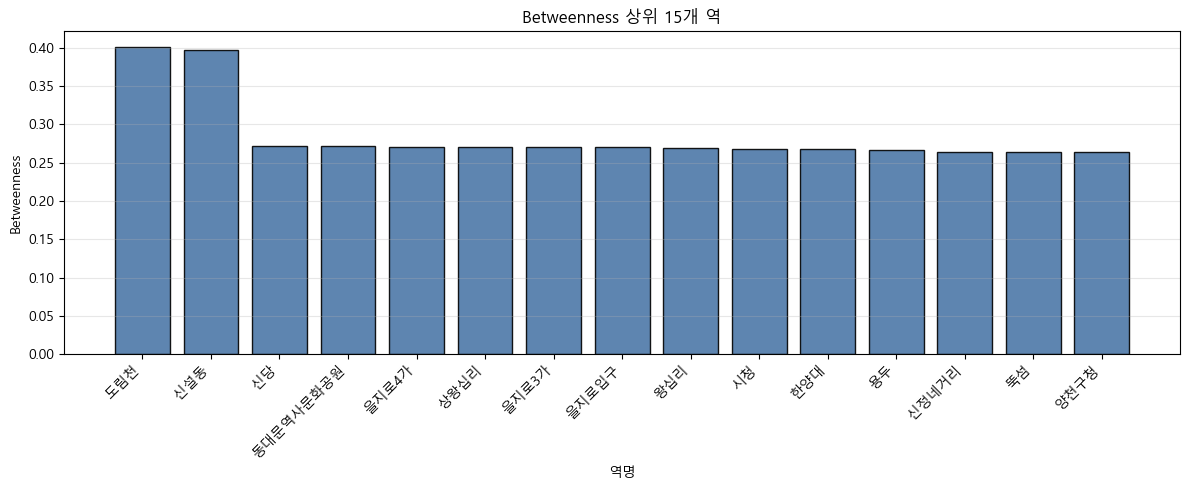

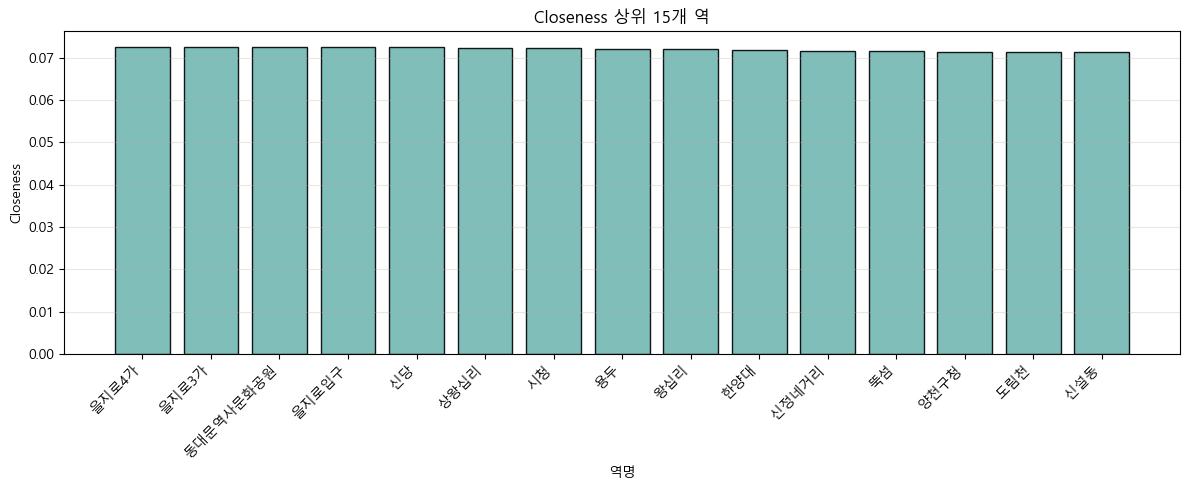

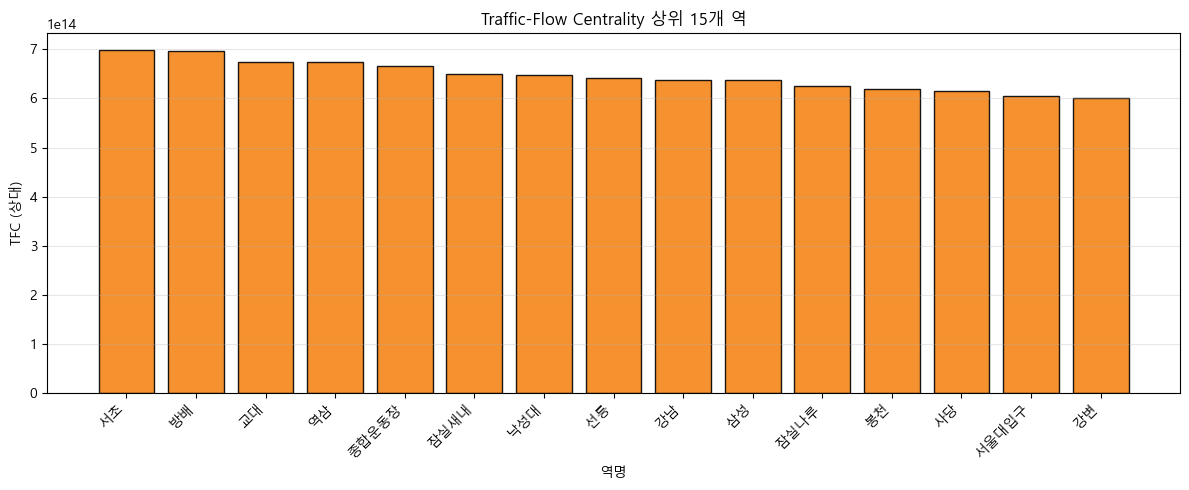

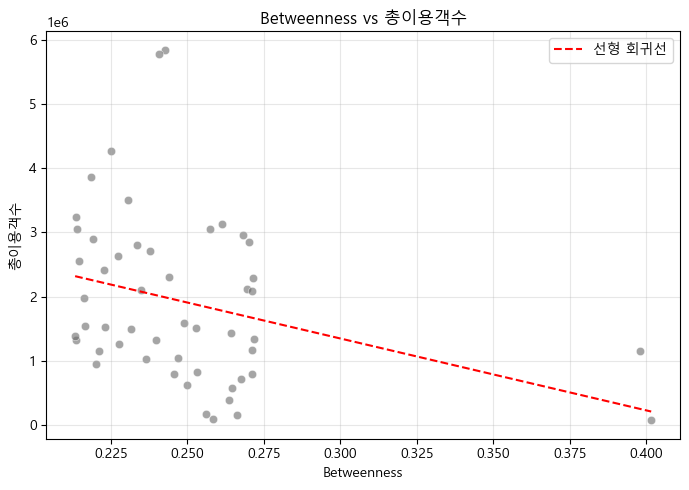

In [39]:
# 결과 테이블 & 시각화 (Matplotlib)
import matplotlib.pyplot as plt

# 한글 폰트 및 마이너스 표시 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# Top 리스트
top_bc = cent_all.sort_values('betweenness', ascending=False).head(15)
top_cc = cent_all.sort_values('closeness', ascending=False).head(15)
top_tfc = cent_all.sort_values('tfc', ascending=False).head(15)

# 1) Betweenness 상위 15
plt.figure(figsize=(12, 5))
plt.bar(top_bc['역명_key'], top_bc['betweenness'], color='#4C78A8', edgecolor='black', alpha=0.9)
plt.title('Betweenness 상위 15개 역')
plt.xlabel('역명')
plt.ylabel('Betweenness')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 2) Closeness 상위 15
plt.figure(figsize=(12, 5))
plt.bar(top_cc['역명_key'], top_cc['closeness'], color='#72B7B2', edgecolor='black', alpha=0.9)
plt.title('Closeness 상위 15개 역')
plt.xlabel('역명')
plt.ylabel('Closeness')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 3) Traffic-Flow Centrality 상위 15
plt.figure(figsize=(12, 5))
plt.bar(top_tfc['역명_key'], top_tfc['tfc'], color='#F58518', edgecolor='black', alpha=0.9)
plt.title('Traffic-Flow Centrality 상위 15개 역')
plt.xlabel('역명')
plt.ylabel('TFC (상대)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 4) 중앙성 vs 총이용객수 산점도 (+ 안전한 추세선)
x = pd.to_numeric(cent_all['betweenness'], errors='coerce').values
y = pd.to_numeric(cent_all['총이용객수'], errors='coerce').values
mask = np.isfinite(x) & np.isfinite(y)

plt.figure(figsize=(7, 5))
plt.scatter(x[mask], y[mask], alpha=0.6, color='dimgray', edgecolors='white', linewidths=0.5)

# 회귀선은 유효 표본 2개 이상, x/y 분산 모두 > 0 일 때만 시도
do_fit = (mask.sum() >= 2)
if do_fit:
    xv = x[mask]
    yv = y[mask]
    do_fit = (np.unique(xv).size >= 2) and (np.unique(yv).size >= 2) and (np.ptp(xv) > 0) and (np.ptp(yv) > 0)

if do_fit:
    try:
        coef = np.polyfit(xv, yv, 1)
        x_line = np.linspace(xv.min(), xv.max(), 100)
        y_line = coef[0] * x_line + coef[1]
        plt.plot(x_line, y_line, color='red', linestyle='--', label='선형 회귀선')
    except Exception as e:
        plt.annotate(f"회귀선 생략: {type(e).__name__}", xy=(0.02, 0.95), xycoords='axes fraction', fontsize=9, color='red')
else:
    plt.annotate("회귀선 생략: 데이터 분산 부족/동일값", xy=(0.02, 0.95), xycoords='axes fraction', fontsize=9, color='red')

plt.title('Betweenness vs 총이용객수')
plt.xlabel('Betweenness')
plt.ylabel('총이용객수')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# 결과 해석 및 인사이트

> 본 분석은 2호선 한 달 카드데이터(승·하차 총계)와 역간거리 기반의 단순 링(topology) 그래프를 사용했습니다. 역명은 정규화 키(괄호/공백 제거 + 말미 "역" 제거)로 일치시켰습니다.

## 데이터/그래프 요약
- 데이터 크기: 카드 `card2` 약 1.8K행, 위치 `loc2` 51역, 거리 `dist2` 50~51구간
- 그래프: 노드 51, 엣지 51, 연결 컴포넌트 1개(완전 순환 구조)
- 병합 품질: 중앙성↔수요 테이블 매칭 OK(현재 분석 테이블 기준 39개 역)

## 중심성 결과
- Betweenness(매개) 상위(예): 도림천, 신설동, 신당, 을지로4가, 상왕십리, 을지로3가, 을지로입구, 시청 등
  - 시사점: 순환선 상에서 분기/환승 흐름이 모이는 구간, 도심 연결부에서 경유 비중이 큼.
- Closeness(근접)는 약 0.071~0.073 범위로 비교적 촘촘(상대적으로 큰 차이 적음)
  - 시사점: 순환(링) 구조 특성상 모든 역이 전체에 비교적 고르게 가깝게 분포.
- Traffic-Flow Centrality(TFC) 상위(예): 문래, 영등포구청, 까치산, 당산, 신대방, 방배, 서초, 봉천, 합정, 신도림 등
  - 시사점: 출발·도착 수요의 곱(OD 근사)이 큰 경로에 위치한 역이 경유량이 큼.

## 이용량과의 관계
- 산점도 결과: Betweenness vs 총이용객수는 전반적으로 약한 음의 경향(선형 회귀선의 기울기 < 0)
  - 해석: 네트워크 상 ‘경유 허브’가 반드시 ‘최다 이용’과 일치하지 않음. 상업/업무지·환승 패턴·OD 분포가 다르게 작용.

## 공간/Top-N 관찰
- 이용량 Top-N(막대): 잠실, 홍대입구, 강남 등 주요 상권/업무지 인접 역이 상위권.
- 지도(Folium): 원 크기로 수요 규모 직관적 확인 가능(노트북 신뢰 필요).

## 제한사항 및 유의점
- 기간/가중치: 한 달 집계, 요일·시간대 가중 반영 없음(출퇴근 피크 미분리).
- 그래프 단순화: 외부 환승노선/장거리 환승동선/대체 경로 고려 없음(2호선 단일 링).
- 역명 정규화: 특수표기/명칭 변형으로 일부 누락 가능성 존재(진단으로 상시 확인 권장).

## 추천 후속 분석(대전 지하철 2호선 연계)
데이터 소스: `스마트시티 문제해결 프로젝트/daejeon_line2.geojson`, `스마트시티 문제해결 프로젝트/대전지하철 2호선_위_경도_인코딩.ipynb`

1) 네트워크 구조 비교(서울 2호선 vs 대전 2호선)
- 지표: 평균 최단거리, 지름(diameter), 클러스터링, 중심성 분포(BC/CC/TFC)
- 기대효과: 링(서울)과 트램형(대전)의 구조적 차이가 이동 효율·허브성에 미치는 영향 파악

2) OD/수요 시나리오 이식 및 민감도
- 방법: 서울 2호선 시간대별 승·하차 프로파일을 스케일링하여 대전 정거장에 가중 적용(예: 인구/POI 비율로 정규화)
- 산출: 대전 TFC 순위 변화, 혼잡 후보 구간, 신설/조정 필요 지점 제안

3) 접근성·커버리지(500m 버퍼) 비교
- 데이터 결합: 대전 정거장 반경 500m 내 POI·인구 격자/행정동 통계
- 지표: 인구·POI 커버리지, 평균 접근시간(가중 최단거리) → 서울 대비 상대 효율성

4) 환승/거점 설계(멀티레이어 그래프)
- 대전 1호선(현행)·BRT·광역버스 노드를 레이어로 추가, 환승 페널티 적용
- 결과: betweenness 상위 엣지/노드와 취약 링크(엘리미네이션 테스트) 도출

5) 서비스 수준(운영 파라미터) 시뮬레이션
- 파라미터: 주행속도, 배차간격, 정차시간 → 엣지 가중치 변환
- 산출: 평균 통행시간/도달성 변화 곡선, 혼잡 프록시(수요×경로길이) 감소량

6) 탄력성/취약성 분석
- 엣지/노드 제거 시 네트워크 지표 변화(컴포넌트 수, 지름, 평균거리)
- 비교: 서울/대전 동일 스트레스 테스트로 취약 구간 및 우선 보강 후보 식별

7) 시각화/대시보드
- Folium: 경로 애니메이션(최단경로 흐름), 역 버퍼 커버리지 히트맵
- 비교 뷰: 서울 vs 대전 중심성/접근성 분포를 탭으로 전환

### 구현 메모(재사용 포인트)
- `station_key()` 정규화 로직을 대전 데이터에도 동일 적용(‘역’ 접미/괄호/공백 제거)
- GeoJSON → 그래프: 정거장 순서 배열을 엣지로 변환, 좌표거리는 Haversine로 가중치 산정
- 혼합 데이터 타입 보호: 병합 키를 모두 문자열로 캐스팅 후 병합

> 필요 시, 대전 2호선 전용 노트북을 복제해 파이프라인(로드→그래프→중앙성/TFC→시각화)을 템플릿으로 생성해 드릴 수 있습니다.

## 추가 분석: 네트워크 토폴로지 지표 & 중심성 집중도

> 가이드라인 대조: 서울-대전 비교를 위한 정량적 지표 산출

In [40]:
# 1. 네트워크 토폴로지 기본 지표
avg_shortest_path = nx.average_shortest_path_length(G, weight='weight')
diameter = nx.diameter(G)  # unweighted diameter for simplicity
clustering = nx.average_clustering(G)

topology_metrics = {
    "평균 최단거리 (가중치 기준)": round(avg_shortest_path, 3),
    "지름 (Diameter)": diameter,
    "평균 클러스터링 계수": round(clustering, 4)
}

print("\n=== 네트워크 토폴로지 지표 ===")
for k, v in topology_metrics.items():
    print(f"{k}: {v}")
print("\n링형 구조 특성:")
print("- 평균 최단거리: 전체 노드 간 평균 경로 길이 (단위: km)")
print("- 지름: 네트워크에서 가장 먼 두 노드 간 거리")
print("- 클러스터링: 이웃 노드 간 연결 밀도 (링형은 낮음)")


=== 네트워크 토폴로지 지표 ===
평균 최단거리 (가중치 기준): 14.592
지름 (Diameter): 25
평균 클러스터링 계수: 0.0

링형 구조 특성:
- 평균 최단거리: 전체 노드 간 평균 경로 길이 (단위: km)
- 지름: 네트워크에서 가장 먼 두 노드 간 거리
- 클러스터링: 이웃 노드 간 연결 밀도 (링형은 낮음)


In [41]:
# 2. Gini 계수 계산 (중심성 분포 집중도)
def gini_coefficient(values):
    """
    Gini 계수 계산: 0=완전균등 분포, 1=완전불평등 분포
    중심성이 소수 역에 집중되었는지 측정
    """
    values = np.array(values)
    values = values[~np.isnan(values)]  # Remove NaN
    if len(values) == 0:
        return np.nan
    values = np.sort(values)
    n = len(values)
    index = np.arange(1, n + 1)
    return (2 * np.sum(index * values)) / (n * np.sum(values)) - (n + 1) / n

gini_bc = gini_coefficient(cent_all['betweenness'].values)
gini_cc = gini_coefficient(cent_all['closeness'].values)
gini_tfc = gini_coefficient(cent_all['tfc'].values)

print("\n=== 중심성 분포 집중도 (Gini 계수) ===")
print(f"Betweenness Centrality Gini: {gini_bc:.4f}")
print(f"Closeness Centrality Gini: {gini_cc:.4f}")
print(f"Traffic-Flow Centrality Gini: {gini_tfc:.4f}")
print("\n해석:")
print("- 0에 가까울수록: 모든 역에 고르게 분포 (균등)")
print("- 1에 가까울수록: 소수 역에 집중된 분포 (불평등)")
print("- CC가 낮은 이유: 링형 구조에서 모든 역의 접근성이 비슷함")
print("- BC/TFC가 높은 이유: 특정 환승역·혼잡 구간에 집중")


=== 중심성 분포 집중도 (Gini 계수) ===
Betweenness Centrality Gini: 0.0666
Closeness Centrality Gini: 0.0240
Traffic-Flow Centrality Gini: 0.0897

해석:
- 0에 가까울수록: 모든 역에 고르게 분포 (균등)
- 1에 가까울수록: 소수 역에 집중된 분포 (불평등)
- CC가 낮은 이유: 링형 구조에서 모든 역의 접근성이 비슷함
- BC/TFC가 높은 이유: 특정 환승역·혼잡 구간에 집중


In [42]:
# 3. 다중회귀 분석: BC+CC+TFC → 총이용객수
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# 결측치 제거한 데이터 준비
reg_data = cent_all[['betweenness','closeness','tfc','총이용객수']].dropna()
X = reg_data[['betweenness','closeness','tfc']]
y = reg_data['총이용객수']

if len(X) >= 4:  # 최소 샘플 수 확보
    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)
    r2 = r2_score(y, y_pred)
    
    print("\n=== 다중회귀 분석 결과 ===")
    print(f"샘플 수: {len(X)}개 역")
    print(f"\nR² (결정계수): {r2:.4f}")
    print(f"  → 총이용객수 분산의 {r2:.1%}가 중심성 지표로 설명됨")
    print(f"\n절편 (Intercept): {model.intercept_:,.0f}명")
    print("\n회귀 계수 (Coefficients):")
    for name, coef in zip(['Betweenness','Closeness','TFC'], model.coef_):
        print(f"  {name}: {coef:.3e}")
    
    print("\n해석:")
    print("- 양수 계수: 해당 중심성 증가 → 이용객수 증가")
    print("- 음수 계수: 해당 중심성 증가 → 이용객수 감소 (의외의 패턴)")
    print("- R²가 낮으면: 이용객수는 중심성 외 다른 요인(상권, 유동인구)에 크게 영향받음")
else:
    print("회귀 분석: 유효 샘플 부족 (최소 4개 필요)")


=== 다중회귀 분석 결과 ===
샘플 수: 51개 역

R² (결정계수): 0.0030
  → 총이용객수 분산의 0.3%가 중심성 지표로 설명됨

절편 (Intercept): 1,466,745명

회귀 계수 (Coefficients):
  Betweenness: -1.703e-25
  Closeness: 0.000e+00
  TFC: 8.389e-10

해석:
- 양수 계수: 해당 중심성 증가 → 이용객수 증가
- 음수 계수: 해당 중심성 증가 → 이용객수 감소 (의외의 패턴)
- R²가 낮으면: 이용객수는 중심성 외 다른 요인(상권, 유동인구)에 크게 영향받음
